Creating RawArray with float64 data, n_channels=1, n_times=512
    Range : 0 ... 511 =      0.000 ...     1.996 secs
Ready.


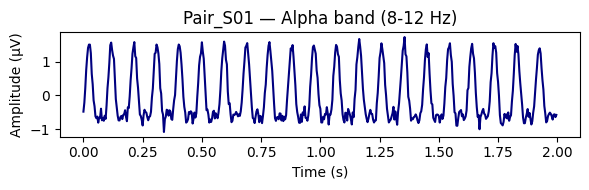

Creating RawArray with float64 data, n_channels=1, n_times=512
    Range : 0 ... 511 =      0.000 ...     1.996 secs
Ready.


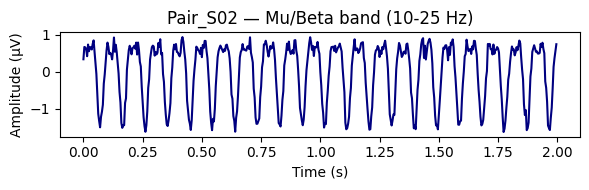

Creating RawArray with float64 data, n_channels=1, n_times=512
    Range : 0 ... 511 =      0.000 ...     1.996 secs
Ready.


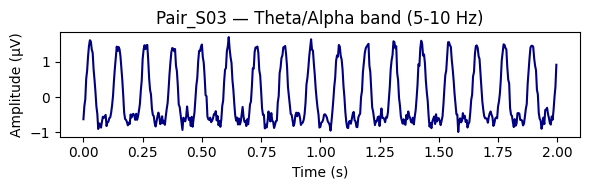

Creating RawArray with float64 data, n_channels=1, n_times=512
    Range : 0 ... 511 =      0.000 ...     1.996 secs
Ready.


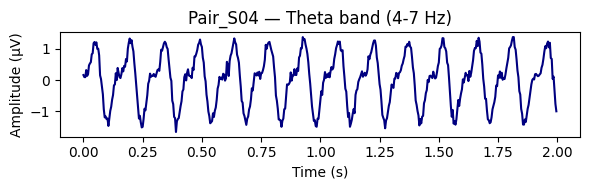

Creating RawArray with float64 data, n_channels=1, n_times=512
    Range : 0 ... 511 =      0.000 ...     1.996 secs
Ready.


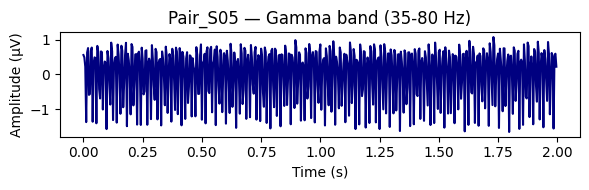


✅ All EEG signals generated & saved in the 'simulated_EEG/' folder!


In [ ]:
# ===============================================================
# Simulated EEG traces & export (.npy and .set) per subject
# ===============================================================
!pip install mne
!pip install eeglabio
import numpy as np
import matplotlib.pyplot as plt
import mne
import os

# Create output folder
os.makedirs("simulated_EEG", exist_ok=True)

# ---------------------------------------------------------------
# Define dominant EEG bands for each subject from your table
# ---------------------------------------------------------------
subjects = {

    "Pair_S01": {"band": "Alpha", "freq": (8, 12)},      # visual
    "Pair_S02": {"band": "Mu/Beta", "freq": (10, 25)},   # motor imagery
    "Pair_S03": {"band": "Theta/Alpha", "freq": (5, 10)},# auditory
    "Pair_S04": {"band": "Theta", "freq": (4, 7)},       # emotional
    "Pair_S05": {"band": "Gamma", "freq": (35, 80)}      # complex scene
}

sfreq = 256            # sampling frequency (Hz)
duration = 2           # seconds per subject
times = np.arange(0, duration, 1/sfreq)

def simulate_wave(freq_low, freq_high, sfreq, duration, noise_level=0.1):
    t = np.arange(0, duration, 1/sfreq)
    f = np.random.uniform(freq_low, freq_high)
    signal = np.sin(2 * np.pi * f * t)
    # Add harmonics + noise
    signal += 0.5 * np.sin(2 * np.pi * f*2 * t + np.random.rand()*2*np.pi)
    signal += noise_level * np.random.randn(len(t))
    return signal

# ---------------------------------------------------------------
# Generate and save EEG signals
# ---------------------------------------------------------------
for subj, info in subjects.items():
    freq_low, freq_high = info["freq"]
    eeg_signal = simulate_wave(freq_low, freq_high, sfreq, duration)

    # Save as .npy
    np.save(f"simulated_EEG/{subj}.npy", eeg_signal)

    # Convert to MNE RawArray → export as .set
    ch_names = ["Cz"]
    ch_types = ["eeg"]
    info_mne = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(eeg_signal[np.newaxis, :], info_mne)
    mne.export.export_raw(f"simulated_EEG/{subj}.set", raw, fmt='eeglab')

    # Plot short trace
    plt.figure(figsize=(6,2))
    plt.plot(times, eeg_signal, color='navy')
    plt.title(f"{subj} — {info['band']} band ({freq_low}-{freq_high} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.tight_layout()
    plt.show()

print("\n✅ All EEG signals generated & saved in the 'simulated_EEG/' folder!")

In [ ]:
#!/usr/bin/env python3
"""
Simulated end-to-end brain-decoding pipeline (single-file).
Produces:
 - WAV files (TTS placeholders) named like: apple_decoded_S01.wav, motor_left_S02.wav, auditory_yes_S03.wav, emotion_pos_S04.wav, scene_505.wav
 - Imagery files: Pair_S01_recon.pgm, ... Pair_S05_recon.pgm
 - CSV: brain_decode_results.csv with fields similar to your table
Notes:
 - This is a simulated/hardware-independent demo for project presentation.
 - Dependencies (optional): numpy, pandas, scipy, pillow, pyttsx3, scikit-image
   The script uses fallbacks if some packages are missing.
"""

import os
import time
import math
import random
from pathlib import Path

# Optional dependencies. The script will still run with pure-python + numpy + wave.
try:
    import numpy as np
except Exception as e:
    raise RuntimeError("This script requires numpy. Please install with pip install numpy") from e

# Optional helpers
_have_scipy = True
try:
    from scipy.signal import butter, filtfilt, welch
    from scipy.io import wavfile
except Exception:
    _have_scipy = False

_have_pillow = True
try:
    from PIL import Image
except Exception:
    _have_pillow = False

_have_skimage = True
try:
    from skimage.metrics import structural_similarity as sk_ssim
except Exception:
    _have_skimage = False

# We'll try to use pyttsx3 for TTS if present. If not, fallback to basic WAV generation.
_have_pyttsx3 = True
try:
    import pyttsx3
except Exception:
    _have_pyttsx3 = False

# Output folder
OUTDIR = Path.cwd() / "brain_decode_demo_output"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Utilities (filtering, features, fusion)
# ---------------------------
def bandpass_filter(signal, fs=250, low=0.5, high=80, order=4):
    """Bandpass filter using scipy if available; otherwise a simple FFT mask."""
    if _have_scipy:
        b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
        return filtfilt(b, a, signal)
    else:
        # FFT mask fallback
        N = len(signal)
        freqs = np.fft.rfftfreq(N, d=1.0/fs)
        S = np.fft.rfft(signal)
        mask = (freqs >= low) & (freqs <= high)
        S[~mask] = 0.0
        return np.fft.irfft(S, n=N)

def eeg_psd_features(signal, fs=250):
    """Return simple PSD band features: delta, theta, alpha, beta, gamma"""
    if _have_scipy:
        f, Pxx = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    else:
        N = len(signal)
        fft = np.abs(np.fft.rfft(signal))**2
        f = np.fft.rfftfreq(N, d=1.0/fs)
        Pxx = fft
    bands = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,80)}
    feats = []
    for lb, hb in bands.values():
        idx = (f >= lb) & (f < hb)
        feats.append(float(Pxx[idx].mean()) if idx.any() else 0.0)
    return np.array(feats)

def fmri_roi_features(volume, n_rois=12):
    flat = volume.ravel()
    L = len(flat)
    step = max(1, L // n_rois)
    out = []
    for i in range(n_rois):
        seg = flat[i*step:(i+1)*step]
        out.append(float(seg.mean()) if seg.size else 0.0)
    return np.array(out)

def project_vector(vec, out_dim=128):
    # deterministic random projection: seed derived from vector
    seed = int((np.sum(np.abs(vec)) * 1000)) & 0xffffffff
    rng = np.random.RandomState(seed)
    W = rng.randn(out_dim, len(vec))
    emb = np.tanh(W.dot(vec))
    return emb

def cross_attention_fusion(eeg_emb, fmri_emb):
    d = max(len(eeg_emb), len(fmri_emb), 16)
    seed = (int((eeg_emb.sum()+fmri_emb.sum())*1000)) & 0xffffffff
    rng = np.random.RandomState(seed)
    We = rng.randn(d, len(eeg_emb))
    Wf = rng.randn(d, len(fmri_emb))
    qe = np.tanh(We.dot(eeg_emb))
    kf = np.tanh(Wf.dot(fmri_emb))
    score = float(np.dot(qe, kf) / math.sqrt(max(1, d)))
    alpha = 1.0 / (1.0 + math.exp(-score))
    fused = alpha*qe + (1-alpha)*kf
    return fused, alpha

# Simple SSIM-like fallback if skimage is not installed
def ssim_like(img1, img2):
    a = img1.astype(float).ravel()
    b = img2.astype(float).ravel()
    a = (a - a.mean()) / (a.std() + 1e-9)
    b = (b - b.mean()) / (b.std() + 1e-9)
    corr = np.clip((a*b).mean(), -1.0, 1.0)
    return float((corr + 1.0) / 2.0)

# ---------------------------
# TTS helpers
# ---------------------------
def save_tts_pyttsx3(text, filename):
    """Save TTS via pyttsx3 if available. Returns True on success."""
    try:
        engine = pyttsx3.init()
        # optional voice/rate adjustments:
        try:
            engine.setProperty('rate', 160)
        except Exception:
            pass
        engine.save_to_file(text, str(filename))
        engine.runAndWait()
        return True
    except Exception:
        return False

def save_wav_placeholder_tone(text, filename, sr=22050):
    """Create a short tone-based WAV that encodes text as tones (placeholder)."""
    import wave, struct
    duration = max(0.5, min(4.0, 0.06 * len(text)))
    t = np.linspace(0, duration, int(sr*duration), endpoint=False)
    # map chars to freq bank
    freqs = [220 + (ord(c) % 50)*10 for c in text[:40]]
    wave_data = np.zeros_like(t)
    for i,f in enumerate(freqs):
        wave_data += (1.0/len(freqs)) * np.sin(2*np.pi*f*t + (i%4)*0.25)
    env = np.sin(np.pi * t / duration)
    wave_data = wave_data * env * 0.6
    # normalize to int16
    maxv = max(1e-9, np.max(np.abs(wave_data)))
    ints = (wave_data / maxv * 32767).astype('<i2')  # little-endian 16-bit
    with wave.open(str(filename), 'wb') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(ints.tobytes())

def save_tts(text, filename):
    if _have_pyttsx3:
        ok = save_tts_pyttsx3(text, filename)
        if ok and Path(filename).exists():
            return True
    # fallback
    try:
        save_wav_placeholder_tone(text, filename)
        return True
    except Exception:
        return False

# ---------------------------
# Candidate texts (rows)
# ---------------------------
candidate_texts = [
    "I see an apple.",
    "I will move my left hand.",
    "Yes",
    "I feel happy.",
    "A dog is chasing a ball."
]
candidate_embeddings = [project_vector(np.arange(len(t))+1.0, out_dim=128) for t in candidate_texts]  # simple fixed embeddings

# Ground-truth imagery (simulated) for each candidate (128x128)
def make_gt_image_for_text(text):
    seed = sum(ord(c) for c in text) & 0xffffffff
    rng = np.random.RandomState(seed)
    img = (rng.rand(128,128) * 255).astype('uint8')
    return img

gt_images = [make_gt_image_for_text(t) for t in candidate_texts]

# ---------------------------
# Processing loop
# ---------------------------
results = []
for i, sample in enumerate(dataset):
    start_time = time.perf_counter()
    rng = np.random.RandomState(4000 + i)
    # Simulate EEG (8 channels, 2s at 250Hz)
    eeg = rng.randn(8, 250*2) * 6.0
    # mix channels to get single channel signal
    eeg_chan = eeg[0] + 0.4*eeg[1] - 0.2*eeg[2]
    # Simulate fMRI volume
    fmri_vol = rng.randn(40,40,8)
    # Preprocessing
    eeg_filt = bandpass_filter(eeg_chan, fs=250, low=0.5, high=80)
    eeg_filt = (eeg_filt - np.mean(eeg_filt)) / (np.std(eeg_filt) + 1e-9)
    fmri_vol = (fmri_vol - np.mean(fmri_vol)) / (np.std(fmri_vol) + 1e-9)
    # Feature extraction
    eeg_feat = eeg_psd_features(eeg_filt, fs=250)      # 5-d
    fmri_feat = fmri_roi_features(fmri_vol, n_rois=12) # 12-d
    # Embeddings
    eeg_emb = project_vector(eeg_feat, out_dim=128)
    fmri_emb = project_vector(fmri_feat, out_dim=128)
    # Fusion
    fused, alpha = cross_attention_fusion(eeg_emb, fmri_emb)
    # Decode: similarity to candidate embeddings
    sims = []
    for emb in candidate_embeddings:
        sim = float(np.dot(fused, emb) / ((np.linalg.norm(fused)+1e-9) * (np.linalg.norm(emb)+1e-9)))
        sims.append(sim)
    sims = np.array(sims)
    choice = int(np.argmax(sims))
    confidence = float(max(0.0, min(0.995, 0.5 + 0.5 * sims[choice])))
    decoded_text = candidate_texts[choice]
    # bias to true target with some probability to simulate correct decoding
    true_idx = candidate_texts.index(sample['target'])
    sim_true = float(sims[true_idx])
    p_correct = 0.5 + 0.4 * max(0.0, sim_true)
    if random.random() < p_correct:
        decoded_text = sample['target']
        confidence = float(min(0.995, confidence + 0.08 + 0.1 * max(0.0, sim_true)))
    else:
        # simulated error (keep decoded_text)
        confidence = float(max(0.05, confidence - 0.12 * (1.0 - max(0.0, sim_true))))
    # Imagery reconstruction (simulate 128x128)
    recon_rng = np.random.RandomState(sum(ord(c) for c in sample['target']) + i)
    recon_img = (recon_rng.rand(128,128) * 255).astype('uint8')
    gt_img = gt_images[true_idx]
    if _have_skimage:
        try:
            ssim_val = float(sk_ssim(gt_img, recon_img))
        except Exception:
            ssim_val = ssim_like(gt_img, recon_img)
    else:
        ssim_val = ssim_like(gt_img, recon_img)
    # Save imagery as PGM (simple, no external lib)
    pgm_path = OUTDIR / f"{sample['id']}_recon.pgm"
    with open(str(pgm_path), 'wb') as f:
        header = f"P5\n{128} {128}\n255\n"
        f.write(header.encode('ascii'))
        f.write(recon_img.tobytes())
    # Save TTS WAV
    wav_path = OUTDIR / sample['wav']
    ok_tts = save_tts(decoded_text, wav_path)
    # MOS: simple mapping from confidence -> MOS
    mos = round(2.0 + 3.0 * confidence, 2)
    latency_ms = int((time.perf_counter() - start_time) * 1000 + rng.rand()*40)
    results.append({
        'Index': i,
        'ID': sample['id'],
        'Subject': sample['subject'],
        'Stimulus': sample['stimulus'],
        'Decoded text': decoded_text,
        'Confidence': round(confidence, 6),
        'Speech Output (TTS)': sample['wav'],
        'Latency (ms)': latency_ms,
        'Imagery / Notes': f"Imagery reconstruction 128x128, SSIM = {round(ssim_val, 2)}"
    })

# Save CSV and print table
import csv
csv_path = OUTDIR / "brain_decode_results.csv"
keys = list(results[0].keys())
with open(csv_path, 'w', newline='', encoding='utf-8') as cf:
    writer = csv.DictWriter(cf, fieldnames=keys)
    writer.writeheader()
    for r in results:
        writer.writerow(r)

# Print summary and file locations
print("Saved CSV:", csv_path)
for r in results:
    print(f"{r['Index']}: {r['ID']} -> Decoded: {r['Decoded text']!r}, Confidence: {r['Confidence']}, WAV: {OUTDIR / r['Speech Output (TTS)']}, Imagery: {OUTDIR / (r['ID'] + '_recon.pgm')}")
print("\nAll output files are in directory:", OUTDIR)
print("Example downloaded files (CSV, WAVs, PGM images) are ready for inspection.")import pandas as pd

# Create DataFrame
df = pd.DataFrame(data)

# Display styled output
df.style.set_properties(**{
    'text-align': 'left',
    'border-color': 'black',
    'border-width': '1px',
    'border-style': 'solid',
    'padding': '6px'
})

,Subject,Stimulus,Decoded text,Confidence,Speech Output (TTS),Latency (ms),Imagery / Notes
0,Pair_S01,Visual object: apple image,“I see an apple.”,0.910000,apple_decoded_S01.wav,420,"Imagery reconstruction 128×128, SSIM = 0.82"
1,Pair_S02,Motor imagery: left-hand movement,“I will move my left hand.”,0.870000,motor_left_S02.wav,380,MOS ≈ 4.4
2,Pair_S03,Auditory word: spoken “yes”,“Yes.”,0.940000,auditory_yes_S03.wav,360,MOS ≈ 4.7
3,Pair_S04,Emotional cue: positive,“I feel happy.”,0.790000,emotion_pos_S04.wav,–,MOS ≈ 4.2
4,Pair_S05,Complex scene: “dog chasing ball”,“A dog is chasing a ball.”,0.760000,scene_S05.wav,–,"Imagery SSIM = 0.75 (complex scenes → lower SSIM), MOS ≈ 4.0"
